In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist, cifar10


# **Image Cleaning - Scikit-learn**

Objective: To reduce noise, remove irrelevant features, and ensure the data is in a clean and usable state for model training or analysis.

Method Used: Principal Component Analysis (PCA) was applied in this method to reduce dimensionality and clean up noisy pixels.



# **MNIST Dataset**  
- load & preprocess the data
- Apply PCA for noice reduction (we use PCA to reduce the dimensionality and clean the images)
- Visualize the original vs PCA-Cleaned Images



In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images (scale pixel values between 0 and 1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images to apply PCA
x_train_flattened = x_train.reshape(x_train.shape[0], -1)
x_test_flattened = x_test.reshape(x_test.shape[0], -1)

# Feature scaling using StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flattened)
x_test_scaled = scaler.transform(x_test_flattened)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Apply PCA for dimensionality reduction (denoising)
pca = PCA(n_components=50)  # Reduce to 50 components
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

# Reconstruct images from PCA components
x_train_reconstructed = pca.inverse_transform(x_train_pca)
x_test_reconstructed = pca.inverse_transform(x_test_pca)

# Reshape to original image shape
x_train_reconstructed = x_train_reconstructed.reshape(x_train.shape)
x_test_reconstructed = x_test_reconstructed.reshape(x_test.shape)


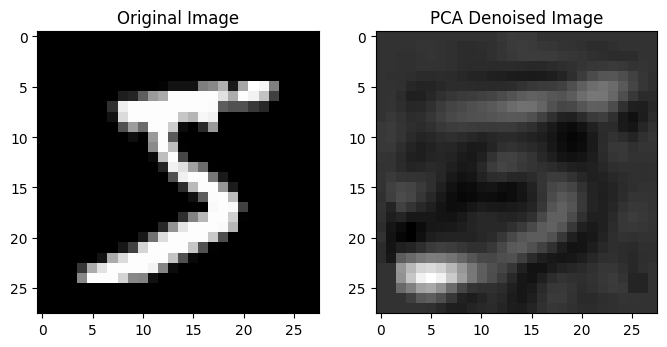

In [4]:
def plot_image(image, ax, title):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Plot the original image
plot_image(x_train[0], axes[0], 'Original Image')

# Plot the PCA denoised image
plot_image(x_train_reconstructed[0], axes[1], 'PCA Denoised Image')

plt.show()


# **CIFAR-10 (for object images)Dataset**  
- load & preprocess the data
- Apply PCA for noice reduction (we use PCA to reduce the dimensionality and clean the images)
- Visualize the original vs PCA-Cleaned Images


In [5]:
# Load CIFAR-10 dataset
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

# Normalize the images (scale pixel values between 0 and 1)
x_train_cifar = x_train_cifar.astype('float32') / 255.0
x_test_cifar = x_test_cifar.astype('float32') / 255.0

# Flatten the images for PCA
x_train_flattened_cifar = x_train_cifar.reshape(x_train_cifar.shape[0], -1)
x_test_flattened_cifar = x_test_cifar.reshape(x_test_cifar.shape[0], -1)

# Feature scaling using StandardScaler
scaler_cifar = StandardScaler()
x_train_scaled_cifar = scaler_cifar.fit_transform(x_train_flattened_cifar)
x_test_scaled_cifar = scaler_cifar.transform(x_test_flattened_cifar)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [6]:
# Apply PCA for CIFAR-10 dataset
pca_cifar = PCA(n_components=100)  # Reduce to 100 components
x_train_pca_cifar = pca_cifar.fit_transform(x_train_scaled_cifar)
x_test_pca_cifar = pca_cifar.transform(x_test_scaled_cifar)

# Reconstruct CIFAR-10 images from PCA components
x_train_reconstructed_cifar = pca_cifar.inverse_transform(x_train_pca_cifar)
x_test_reconstructed_cifar = pca_cifar.inverse_transform(x_test_pca_cifar)

# Reshape back to the original image shape
x_train_reconstructed_cifar = x_train_reconstructed_cifar.reshape(x_train_cifar.shape)
x_test_reconstructed_cifar = x_test_reconstructed_cifar.reshape(x_test_cifar.shape)


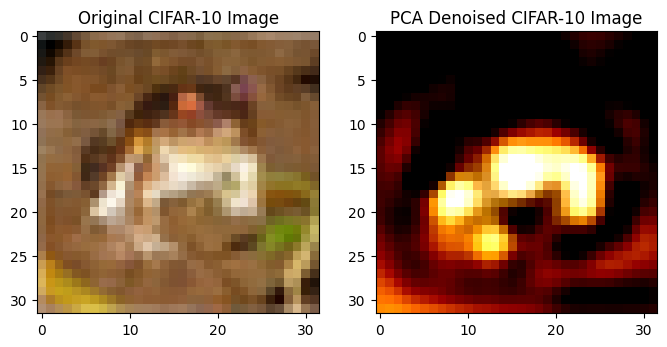

In [7]:
def plot_cifar_image(image, ax, title):
    ax.imshow(image)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Plot the original CIFAR-10 image
plot_cifar_image(x_train_cifar[0], axes[0], 'Original CIFAR-10 Image')

# Plot the PCA denoised CIFAR-10 image
plot_cifar_image(x_train_reconstructed_cifar[0], axes[1], 'PCA Denoised CIFAR-10 Image')

plt.show()
